****Importer libriries****

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

***read df from csv file***

In [18]:
df = pd.read_csv('../data/Clean_Dataset.csv')

****Consultation des premieres observations****

In [3]:
df.head()
# print(df.tail())

,id,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


***Verification des dimensions***

In [4]:
print("Dimensions :", df.shape)

Dimensions : (300153, 12)


***Verification des valeurs manquantes***

In [5]:
print("Valeurs manquantes :")
df.isna().sum()

Valeurs manquantes :


id                  0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

***data info from csv***

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


***describe data from csv***

In [7]:
quantitative_cols = ["duration", "days_left", "price"]

print("Statistiques descriptives :")
df[quantitative_cols].describe()

Statistiques descriptives :


,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


*Columns of data*

In [8]:
df.columns

Index(['id', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='str')

In [9]:
# print(df['class'].unique())

***Verifier les doublons***

In [10]:
print(df.duplicated().sum())

0


| Variable           | Type                  |
| ------------------ | ----------------------|
| airline          | categorielle nominale   |
| flight           | categorielle nominale   |
| source_city      | categorielle nominale   |
| departure_time   | categorielle nominale   |
| stops            | categorielle ordinale   |
| arrival_time     | categorielle nominale   |
| destination_city | categorielle nominale   |
| class            | categorielle nominale   |
| duration         | quantitative continue   |
| days_left        | quantitative discrete   |
| price            | quantitative continue   |


### Variables continues

Les variables continues etudiees sont :

- `duration`
- `days_left`
- `price`

| Statistique | `duration` | `days_left` | `price` |
|---|---:|---:|---:|
| **Count** | 300153 | 300153 | 300153 |
| **Mean** | 12.221 | 26.005 | 20889.661 |
| **Std** | 7.192 | 13.561 | 22697.767 |
| **Min** | 0.830 | 1.000 | 1105.000 |
| **25%** | 6.830 | 15.000 | 4783.000 |
| **50% (Mediane)** | 11.250 | 26.000 | 7425.000 |
| **75%** | 16.170 | 38.000 | 42521.000 |
| **Max** | 49.830 | 49.000 | 123071.000 |

### Variables discretes / categorielles

Les autres variables sont principalement qualitatives et seront etudiees à travers leurs frequences et leur repartition :

| Variable | Type |
|---|---|
| `airline` | Categorielle nominale |
| `flight` | Categorielle nominale |
| `source_city` | Categorielle nominale |
| `departure_time` | Categorielle nominale |
| `stops` | Categorielle ordinale |
| `arrival_time` | Categorielle nominale |
| `destination_city` | Categorielle nominale |
| `class` | Categorielle nominale |


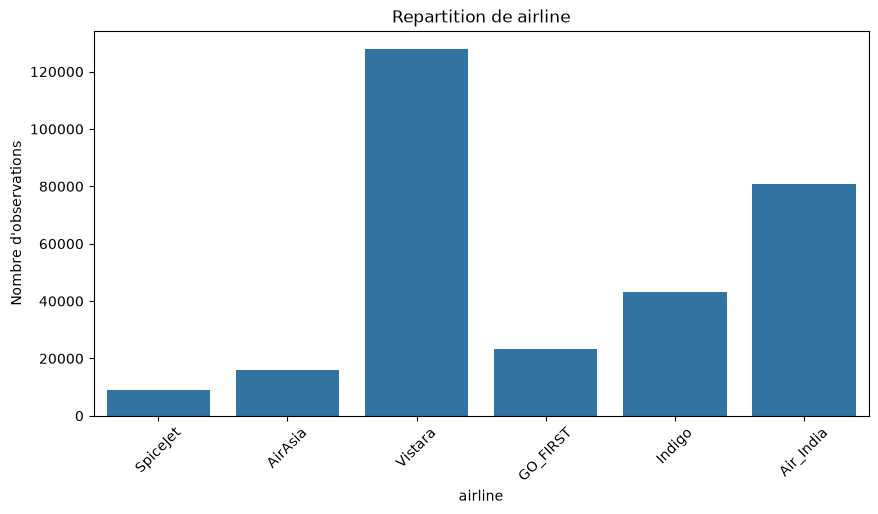

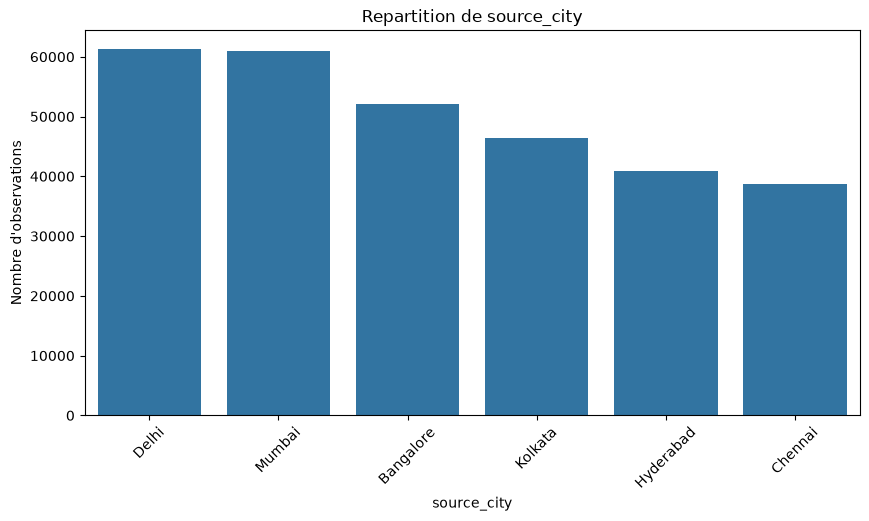

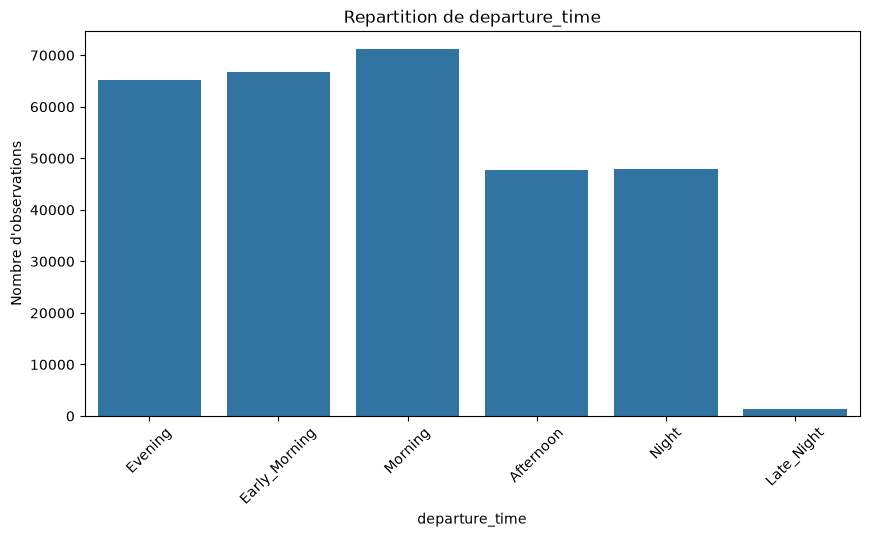

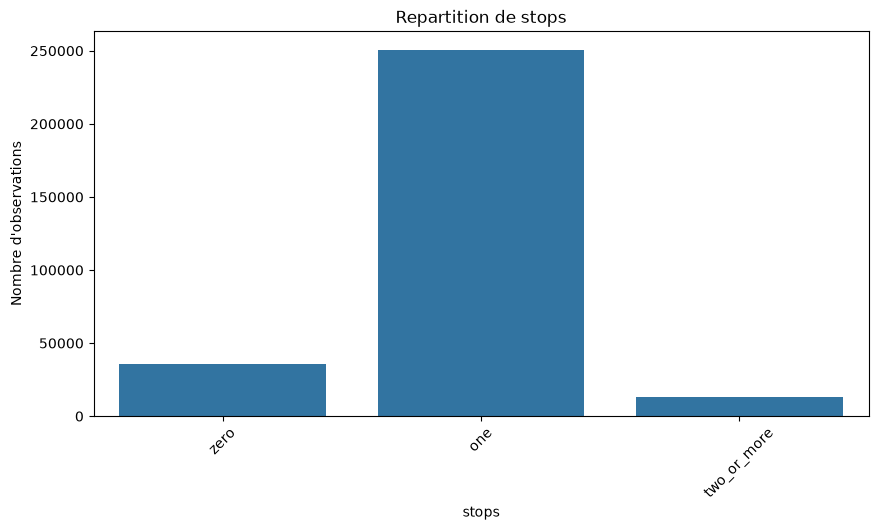

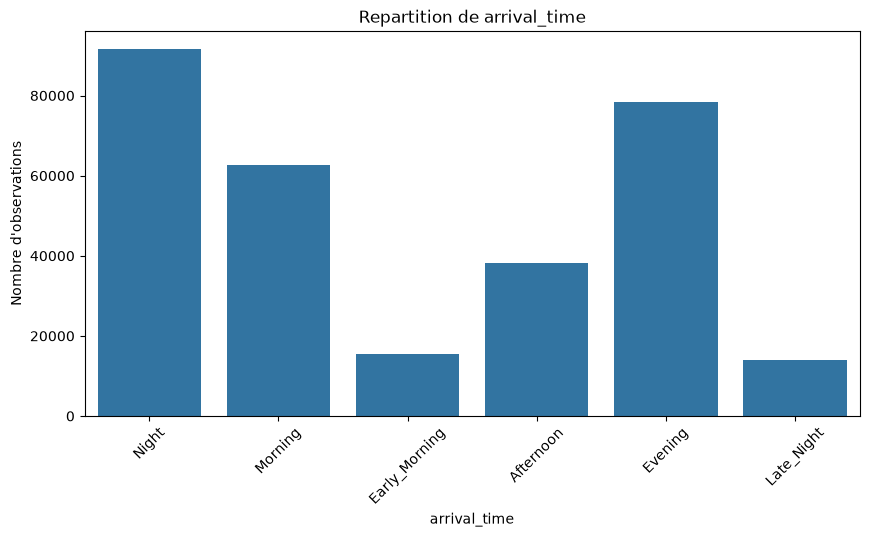

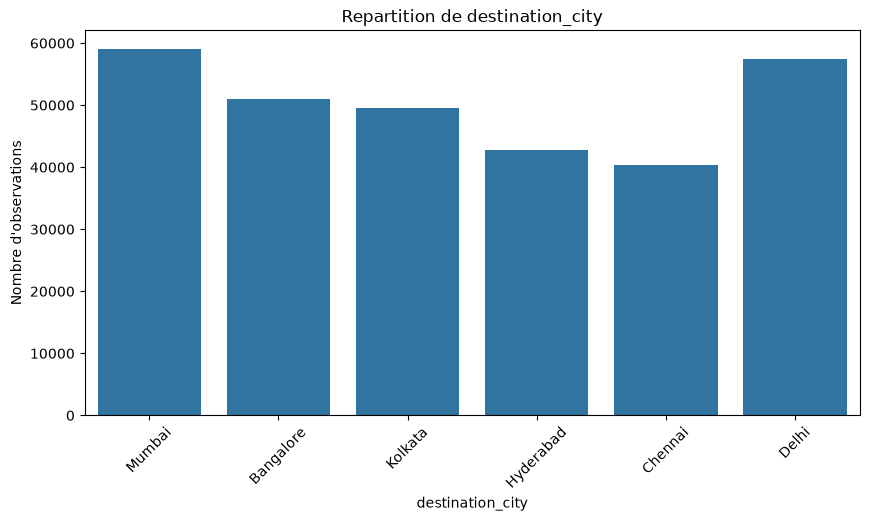

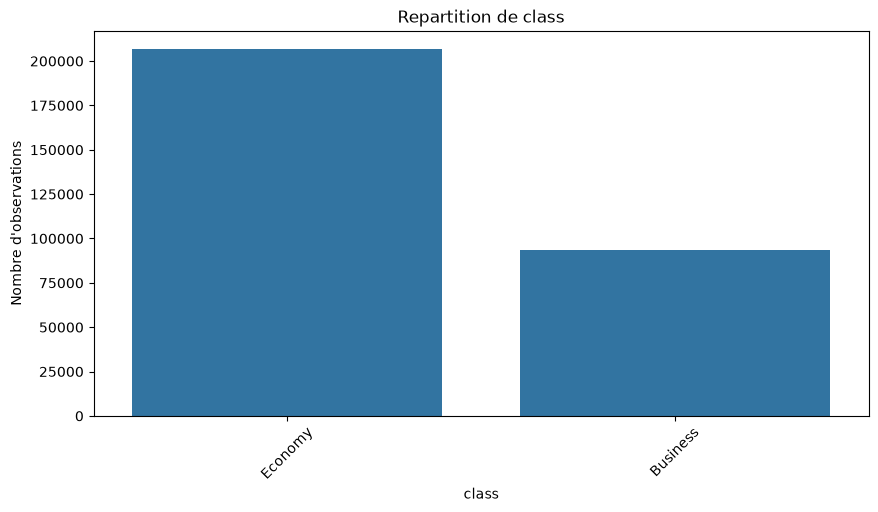

In [11]:
categorical_cols = [
    "airline",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

for col in categorical_cols:
    plt.figure(figsize=(10, 5))

    sns.countplot(data=df, x=col)

    plt.title(f"Repartition de {col}")
    plt.xlabel(col)
    plt.ylabel("Nombre d'observations")

    plt.xticks(rotation=45)
    plt.show()

## Histogramme de price

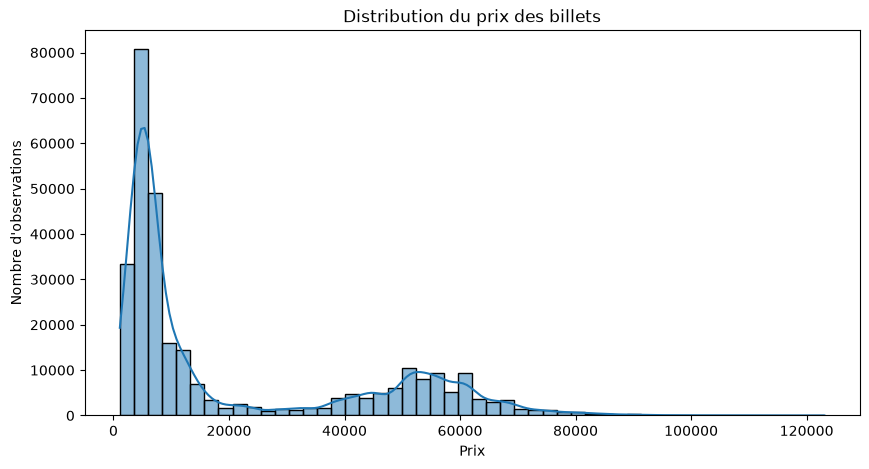

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="price", bins=50, kde=True)

plt.title("Distribution du prix des billets")
plt.xlabel("Prix")
plt.ylabel("Nombre d'observations")

plt.show()

## Boxplot de price

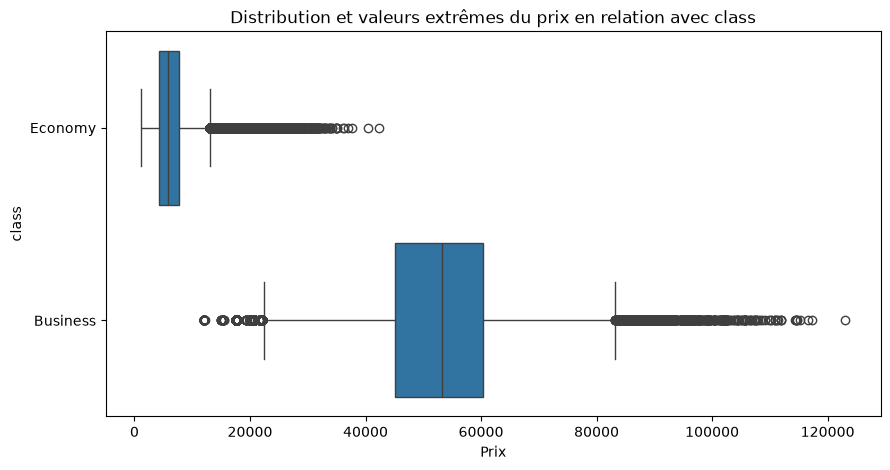

In [13]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="price" , y="class")

plt.title("Distribution et valeurs extrêmes du prix en relation avec class")
plt.xlabel("Prix")

plt.show()

### Interpretation

Le boxplot montre une forte dispersion des prix ainsi qu'une importante
asymetrie à droite. La mediane du prix est d'environ 7 425, tandis que
la moyenne atteint environ 20 890. La presence de nombreux points
au-delà de la moustache superieure indique plusieurs valeurs extrêmes,
avec des prix pouvant depasser 120 000. Ces observations devront être
prises en compte lors de l'analyse et de la modelisation.

### Relation entre la duree du vol et le prix

Chaque point represente un billet. L'axe X represente la duree du vol et l'axe Y son prix. On observe une forte dispersion des prix pour une même duree, donc il n'y a pas de relation lineaire simple entre ces deux variables. La duree peut apporter de l'information au modele, mais elle ne suffit pas à expliquer seule le prix.

In [14]:
pd.crosstab(df['airline'] , df['destination_city'])

destination_city,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
airline,,,,,,
AirAsia,3437,1516,4433,1560,2789,2363
Air_India,11959,11141,14550,12022,13043,18177
GO_FIRST,4386,1488,5509,2576,3794,5420
Indigo,6772,6449,8133,6147,8437,7182
SpiceJet,1088,1172,2541,383,2054,1773
Vistara,23426,18602,22194,20038,19417,24182


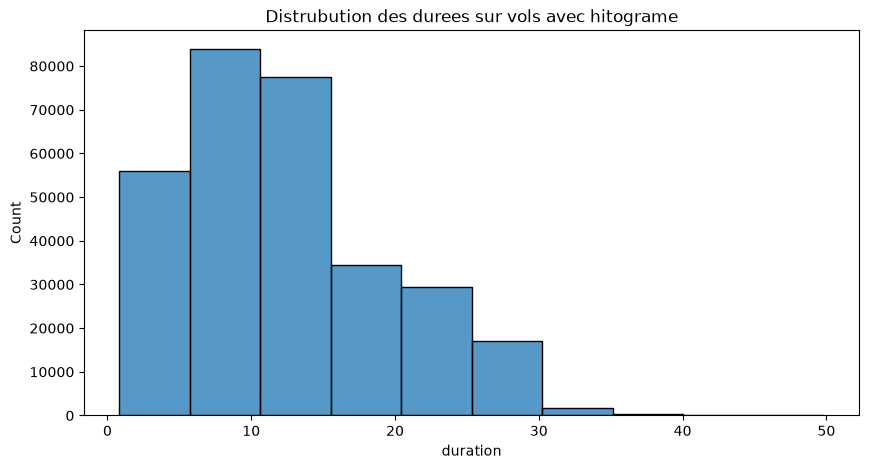

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x="duration" , bins=10)

plt.title("Distrubution des durees sur vols avec hitograme")
# plt.xlabel("Prix")

plt.show()

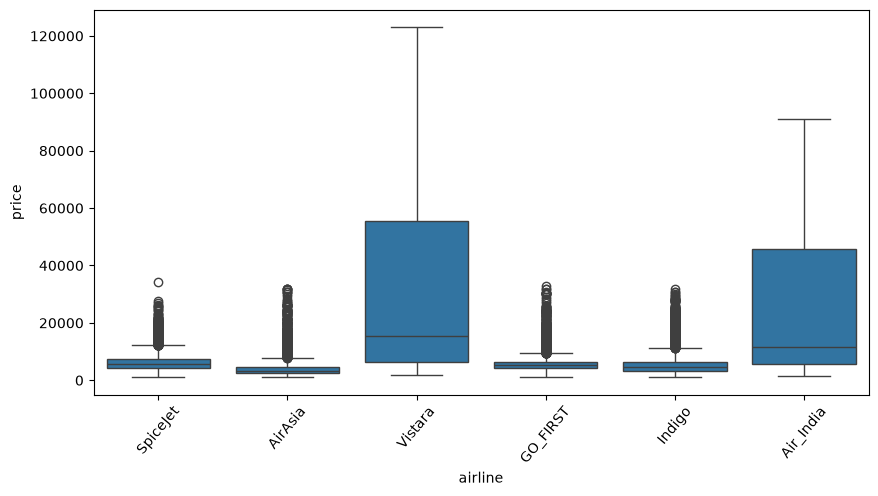

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x = "airline",
    y = "price"
)

plt.xticks(rotation=50)

plt.show()

([0, 1, 2], [Text(0, 0, 'zero'), Text(1, 0, 'one'), Text(2, 0, 'two_or_more')])

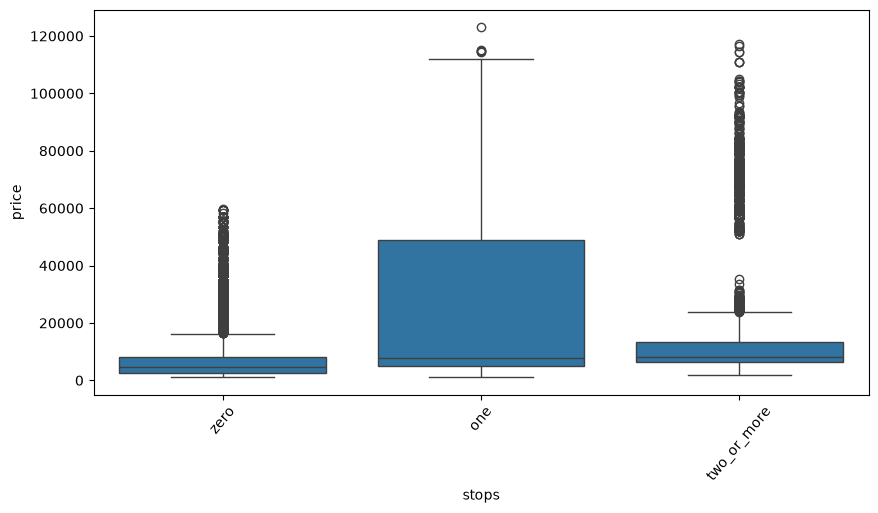

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x = "stops",
    y = "price"
)

plt.xticks(rotation=50)